**Independent Two-Sample t-test**

**Problem**

একজন teacher দুইটি আলাদা group-এর students-কে দুই ধরনের teaching method দিয়েছেন।

Group A → Method A
Group B → Method B

আমরা জানতে চাই:

দুই method-এর students' average score statistically different কি না?

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
method_A = [72, 68, 75, 71, 69, 73, 70, 76, 74, 71,
            67, 72, 70, 69, 75]

method_B = [78, 82, 80, 76, 85, 79, 81, 83, 77, 84,
            80, 82, 79, 86, 81]

In [ ]:
df = pd.DataFrame({
    "Method_A": method_A,
    "Method_B": method_B
})

df.head()

,Method_A,Method_B
0,72,78
1,68,82
2,75,80
3,71,76
4,69,85


In [ ]:
df.shape

(15, 2)

In [ ]:
df.describe()

,Method_A,Method_B
count,15.000000,15.000000
mean,71.466667,80.866667
std,2.722044,2.875181
min,67.000000,76.000000
25%,69.500000,79.000000
50%,71.000000,81.000000
75%,73.500000,82.500000
max,76.000000,86.000000


In [ ]:
print("Method A Mean:", df["Method_A"].mean())
print("Method B Mean:", df["Method_B"].mean())

Method A Mean: 71.46666666666667
Method B Mean: 80.86666666666666


/tmp/ipykernel_1548/1295654919.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


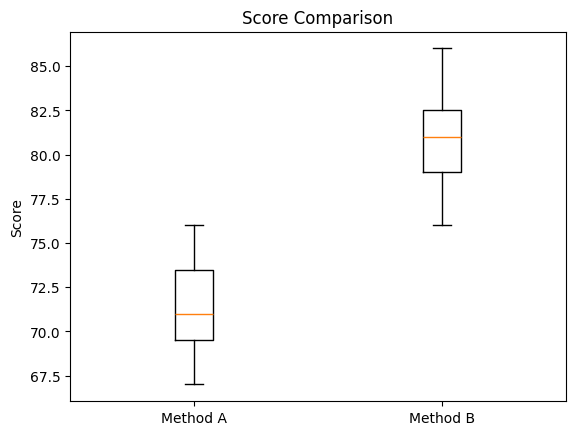

In [ ]:
plt.boxplot(
    [df["Method_A"], df["Method_B"]],
    labels=["Method A", "Method B"]
)

plt.ylabel("Score")
plt.title("Score Comparison")

plt.show()

H₀
Mean A = Mean B

অর্থাৎ দুই teaching method-এর population mean একই।

H₁
Mean A ≠ Mean B

অর্থাৎ population mean আলাদা।

এটা two-tailed test।

In [ ]:
t_test, p_value = stats.ttest_ind(method_A, method_B)
print("t_test:", t_test)
print("p_value:", p_value)

t_test: -9.195031412297995
p_value: 5.934371918339422e-10


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


In [ ]:
if p_value < 0.05:
    print(
        "There is statistically significant evidence "
        "that the mean scores of Method A and Method B differ."
    )
else:
    print(
        "There is not enough statistical evidence "
        "to conclude that the mean scores differ."
    )

There is statistically significant evidence that the mean scores of Method A and Method B differ.


**Real-world data-তে আমরা অনেক সময় Welch's t-test ব্যবহার করি।**

In [ ]:
t_stat, p_value = stats.ttest_ind(
    df["Method_A"],
    df["Method_B"],
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -9.195031412297995
p-value: 6.101896031634468e-10


**Confidence Interval**

In [ ]:
mean_A = df["Method_A"].mean()
mean_B = df["Method_B"].mean()

mean_difference = mean_B - mean_A
print("Mean Difference:", mean_difference)

Mean Difference: 9.399999999999991


In [ ]:
#Welch test-এর CI manually calculation
n_A = len(method_A)
n_B = len(method_B)

var_A = np.var(method_A, ddof=1)
var_B = np.var(method_B, ddof=1)

se = np.sqrt(
    var_A/n_A + var_B/n_B
)

df_welch = (
    (var_A/n_A + var_B/n_B)**2 /
    (
        (var_A/n_A)**2/(n_A-1) +
        (var_B/n_B)**2/(n_B-1)
    )
)

critical_value = stats.t.ppf(
    0.975,
    df_welch
)

lower = mean_difference - critical_value * se
upper = mean_difference + critical_value * se

print("95% CI:", (lower, upper))

95% CI: (np.float64(7.305649250653074), np.float64(11.494350749346909))


**Effect Size — Cohen's d**

In [ ]:
pooled_std = np.sqrt(
    ((n_A - 1) * var_A + (n_B - 1) * var_B)
    / (n_A + n_B - 2)
)

cohens_d = mean_difference / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: 3.3575507476561315


**Paired t-test — Practical Python**

যখন একই ব্যক্তি/বস্তু থেকে দুইবার measurement নেওয়া হয় এবং সেই দুই measurement-এর মধ্যে difference আছে কি না দেখতে চাও।

সবচেয়ে সহজ example:

10 জন student-এর training-এর আগে এবং training-এর পরে test score নেওয়া হলো।
Training-এর পরে score কি significantly পরিবর্তন হয়েছে?

এখানে গুরুত্বপূর্ণ বিষয়:

Before এবং After একই students-এর।

তাই data independent নয় → paired data।

In [ ]:
before = [62, 65, 70, 68, 72, 60, 66, 71, 64, 69]
after = [68, 70, 74, 72, 76, 65, 71, 75, 69, 73]

In [ ]:
df = pd.DataFrame({
    "before": before,
    "after": after
})

df

,before,after
0,62,68
1,65,70
2,70,74
3,68,72
4,72,76
5,60,65
6,66,71
7,71,75
8,64,69
9,69,73


In [ ]:
df["difference"] = df["after"] - df["before"]
df

,before,after,difference
0,62,68,6
1,65,70,5
2,70,74,4
3,68,72,4
4,72,76,4
5,60,65,5
6,66,71,5
7,71,75,4
8,64,69,5
9,69,73,4


In [ ]:
mean_difference = df["difference"].mean()
print("Mean Difference:", mean_difference)

Mean Difference: 4.6


H₀
Mean Difference = 0

অর্থাৎ Before এবং After-এর মধ্যে systematic change নেই।

H₁
Mean Difference ≠ 0

অর্থাৎ meaningful statistical difference আছে।

In [ ]:
t_stat, p_value = stats.ttest_rel(
    df["before"],
    df["after"]
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -20.804282775865687
p-value: 6.411002069400506e-09


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


**অর্থাৎ Before এবং After score-এর মধ্যে statistically significant difference-এর evidence আছে।**

**Visualization**

/tmp/ipykernel_1548/2096627701.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


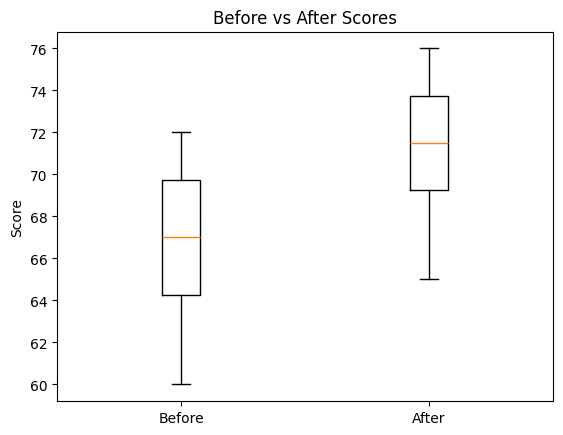

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(
    [df["before"], df["after"]],
    labels=["Before", "After"]
)

plt.ylabel("Score")
plt.title("Before vs After Scores")

plt.show()

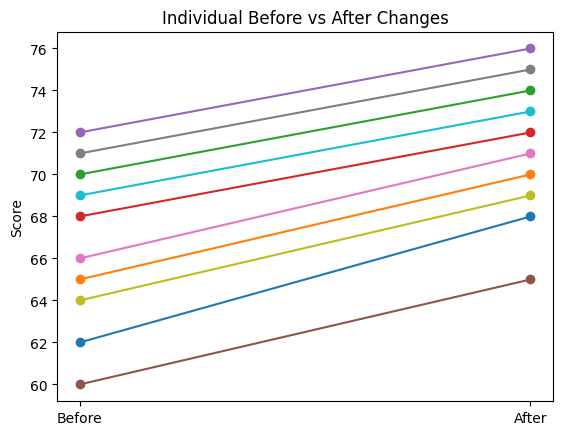

In [ ]:
#paired nature দেখানোর জন্য line plot আরও useful:
for i in range(len(df)):
    plt.plot(
        ["Before", "After"],
        [df.loc[i, "before"], df.loc[i, "after"]],
        marker="o"
    )

plt.ylabel("Score")
plt.title("Individual Before vs After Changes")

plt.show()

এখানে প্রতিটি line একজন student।

যদি বেশিরভাগ line উপরের দিকে যায় → improvement-এর visual evidence পাওয়া যায়

**Confidence Interval**

In [ ]:
difference = df["difference"]

mean_diff = difference.mean()
sem_diff = stats.sem(difference)

ci = stats.t.interval(
    confidence=0.95,
    df=len(difference) - 1,
    loc=mean_diff,
    scale=sem_diff
)

print("Mean Difference:", mean_diff)
print("95% CI:", ci)

Mean Difference: 4.6
95% CI: (np.float64(4.09981823159987), np.float64(5.100181768400129))


এর মানে estimated average improvement-এর plausible range প্রায় 4.0 থেকে 5.1 points।

**Effect Size**

In [ ]:
cohens_d = (
    difference.mean() /
    difference.std(ddof=1)
)

print("Cohen's d:", cohens_d)

Cohen's d: 6.578891865794587


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. Data
before = [62, 65, 70, 68, 72, 60, 66, 71, 64, 69]
after = [68, 70, 74, 72, 76, 65, 71, 75, 69, 73]

# 2. DataFrame
df = pd.DataFrame({
    "before": before,
    "after": after
})

# 3. Difference
df["difference"] = df["after"] - df["before"]

# 4. Descriptive statistics
print(df.describe())

# 5. Mean difference
mean_difference = df["difference"].mean()

print("Mean Difference:", mean_difference)

# 6. Paired t-test
t_stat, p_value = stats.ttest_rel(
    df["before"],
    df["after"]
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

# 7. Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

# 8. Confidence interval
sem_diff = stats.sem(df["difference"])

ci = stats.t.interval(
    confidence=0.95,
    df=len(df) - 1,
    loc=mean_difference,
    scale=sem_diff
)

print("95% CI:", ci)

# 9. Effect size
cohens_d = (
    mean_difference /
    df["difference"].std(ddof=1)
)

print("Cohen's d:", cohens_d)

**Chi-Square Test of Independence**

Students-এর study group এবং exam result-এর মধ্যে কোনো relationship আছে কি না?

এখানে দুইটা variable-ই categorical:

Study_Group → Regular / Irregular
Result → Pass / Fail

In [ ]:
data = {
    "Study_Group": [
        "Regular", "Regular", "Regular", "Regular", "Regular",
        "Regular", "Regular", "Regular", "Regular", "Regular",
        "Irregular", "Irregular", "Irregular", "Irregular", "Irregular",
        "Irregular", "Irregular", "Irregular", "Irregular", "Irregular"
    ],

    "Result": [
        "Pass", "Pass", "Pass", "Pass", "Fail",
        "Pass", "Pass", "Fail", "Pass", "Pass",
        "Pass", "Fail", "Fail", "Pass", "Fail",
        "Fail", "Pass", "Fail", "Fail", "Pass"
    ]
}

df = pd.DataFrame(data)

df.head()

,Study_Group,Result
0,Regular,Pass
1,Regular,Pass
2,Regular,Pass
3,Regular,Pass
4,Regular,Fail


In [ ]:
df.describe()

,Study_Group,Result
count,20,20
unique,2,2
top,Regular,Pass
freq,10,12


In [ ]:
df.describe(include="object")

,Study_Group,Result
count,20,20
unique,2,2
top,Regular,Pass
freq,10,12


In [ ]:
print(df["Study_Group"].unique())
print(df["Result"].unique())

['Regular' 'Irregular']
['Pass' 'Fail']


**Frequency count**

In [ ]:
df["Study_Group"].value_counts()

,count
Study_Group,
Regular,10
Irregular,10


In [34]:
contingency_table = pd.crosstab(
    df["Study_Group"],
    df["Result"]
)

print(contingency_table)

Result       Fail  Pass
Study_Group            
Irregular       6     4
Regular         2     8


In [35]:
#Percentage table
percentage_table = pd.crosstab(
    df["Study_Group"],
    df["Result"],
    normalize="index"
) * 100

print(percentage_table)

Result       Fail  Pass
Study_Group            
Irregular    60.0  40.0
Regular      20.0  80.0


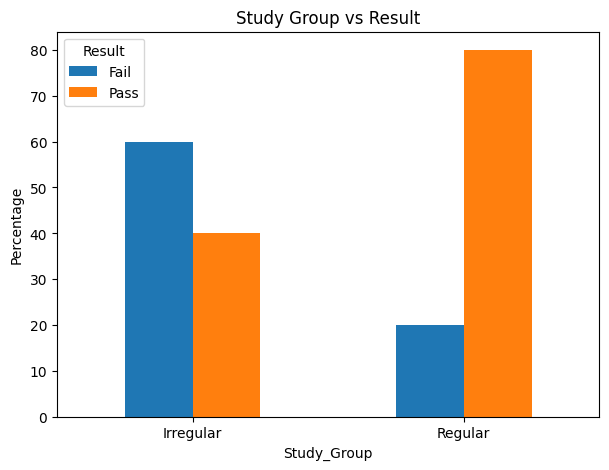

In [36]:
#Visualization
percentage_table.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.ylabel("Percentage")
plt.title("Study Group vs Result")
plt.xticks(rotation=0)
plt.show()

H₀ — Null Hypothesis

Study Group এবং Result-এর মধ্যে কোনো association নেই।

অর্থাৎ:

Study Group ⟂ Result

H₁ — Alternative Hypothesis

Study Group এবং Result-এর মধ্যে association আছে।

In [37]:
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 1.875
p-value: 0.17090352023079358
Degrees of freedom: 1


যদি Study Group এবং Result-এর মধ্যে কোনো relationship না থাকত, তাহলে expected count কত হওয়ার কথা?

In [38]:
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print(expected_df)

Result       Fail  Pass
Study_Group            
Irregular     4.0   6.0
Regular       4.0   6.0


**Observed বনাম Expected**

In [39]:
print("Observed:")
print(contingency_table)

Observed:
Result       Fail  Pass
Study_Group            
Irregular       6     4
Regular         2     8


In [40]:
print("\nExpected:")
print(expected_df)


Expected:
Result       Fail  Pass
Study_Group            
Irregular     4.0   6.0
Regular       4.0   6.0


In [41]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Fail to reject H0


এই sample-এর ভিত্তিতে Study Group এবং Result-এর মধ্যে statistically significant association-এর sufficient evidence পাওয়া যায়নি।

**Effect Size — Cramér's V**

In [42]:
n = contingency_table.to_numpy().sum()

min_dimension = min(
    contingency_table.shape
) - 1

cramers_v = np.sqrt(
    chi2 / (n * min_dimension)
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.30618621784789724


  Study_Group Result
0     Regular   Pass
1     Regular   Pass
2     Regular   Pass
3     Regular   Pass
4     Regular   Fail
(20, 2)
       Study_Group Result
count           20     20
unique           2      2
top        Regular   Pass
freq            10     12

Observed:
Result       Fail  Pass
Study_Group            
Irregular       6     4
Regular         2     8

Percentage:
Result       Fail  Pass
Study_Group            
Irregular    60.0  40.0
Regular      20.0  80.0


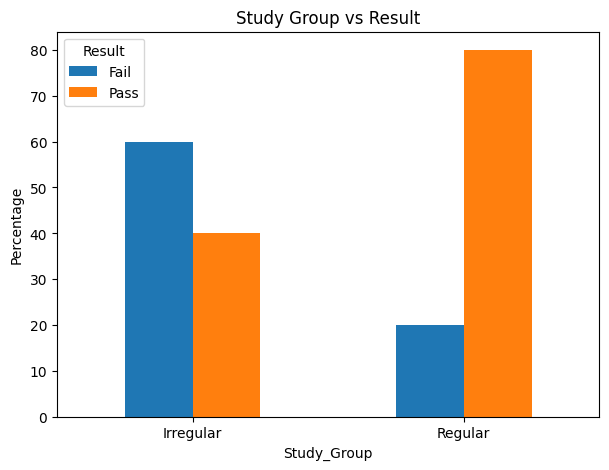


Chi-square: 1.875
p-value: 0.17090352023079358
Degrees of freedom: 1

Expected:
Result       Fail  Pass
Study_Group            
Irregular     4.0   6.0
Regular       4.0   6.0

Fail to reject H0
Cramer's V: 0.30618621784789724


In [43]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# -------------------------
# 1. Create dataset
# -------------------------

data = {
    "Study_Group": [
        "Regular", "Regular", "Regular", "Regular", "Regular",
        "Regular", "Regular", "Regular", "Regular", "Regular",
        "Irregular", "Irregular", "Irregular", "Irregular", "Irregular",
        "Irregular", "Irregular", "Irregular", "Irregular", "Irregular"
    ],

    "Result": [
        "Pass", "Pass", "Pass", "Pass", "Fail",
        "Pass", "Pass", "Fail", "Pass", "Pass",
        "Pass", "Fail", "Fail", "Pass", "Fail",
        "Fail", "Pass", "Fail", "Fail", "Pass"
    ]
}

df = pd.DataFrame(data)

# -------------------------
# 2. Inspect
# -------------------------

print(df.head())
print(df.shape)
print(df.describe(include="object"))

# -------------------------
# 3. Crosstab
# -------------------------

contingency_table = pd.crosstab(
    df["Study_Group"],
    df["Result"]
)

print("\nObserved:")
print(contingency_table)

# -------------------------
# 4. Percentage
# -------------------------

percentage_table = pd.crosstab(
    df["Study_Group"],
    df["Result"],
    normalize="index"
) * 100

print("\nPercentage:")
print(percentage_table)

# -------------------------
# 5. Visualization
# -------------------------

percentage_table.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.ylabel("Percentage")
plt.title("Study Group vs Result")
plt.xticks(rotation=0)
plt.show()

# -------------------------
# 6. Chi-square test
# -------------------------

chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("\nChi-square:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

# -------------------------
# 7. Expected frequencies
# -------------------------

expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("\nExpected:")
print(expected_df)

# -------------------------
# 8. Decision
# -------------------------

alpha = 0.05

if p_value < alpha:
    print("\nReject H0")
else:
    print("\nFail to reject H0")

# -------------------------
# 9. Cramer's V
# -------------------------

n = contingency_table.to_numpy().sum()

min_dimension = min(
    contingency_table.shape
) - 1

cramers_v = np.sqrt(
    chi2 / (n * min_dimension)
)

print("Cramer's V:", cramers_v)